In [1]:
import kagglehub
from pathlib import Path
import pandas as pd

# Download dataset (requires: pip install kagglehub; Kaggle account / API if prompted)
path = Path(kagglehub.dataset_download("yasserh/wine-quality-dataset"))
csv_path = next(path.rglob("*.csv"))
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace(" ", "_")

if "Id" in df.columns:
    df = df.drop(columns=["Id"])

X = df.drop(columns=["quality"])
y = df[["quality"]]

print("Path to dataset files:", path)
print("Using CSV:", csv_path.name)
print(df.shape)
print(df.head())


100%|██████████| 21.5k/21.5k [00:00<00:00, 16.2MB/s]

Extracting files...
Path to dataset files: /Users/mocha/.cache/kagglehub/datasets/yasserh/wine-quality-dataset/versions/1
Using CSV: WineQT.csv
(1143, 12)
   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4     

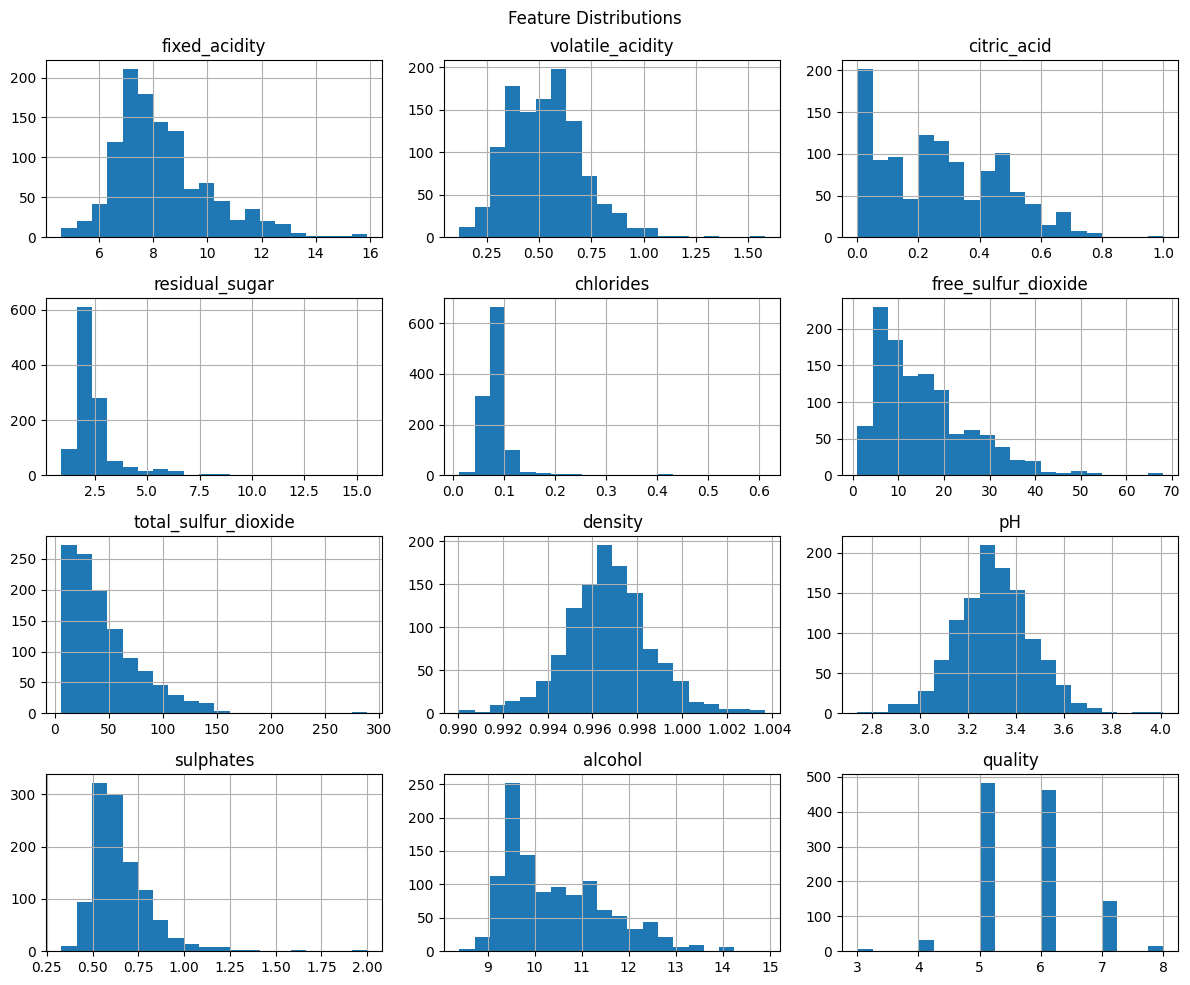

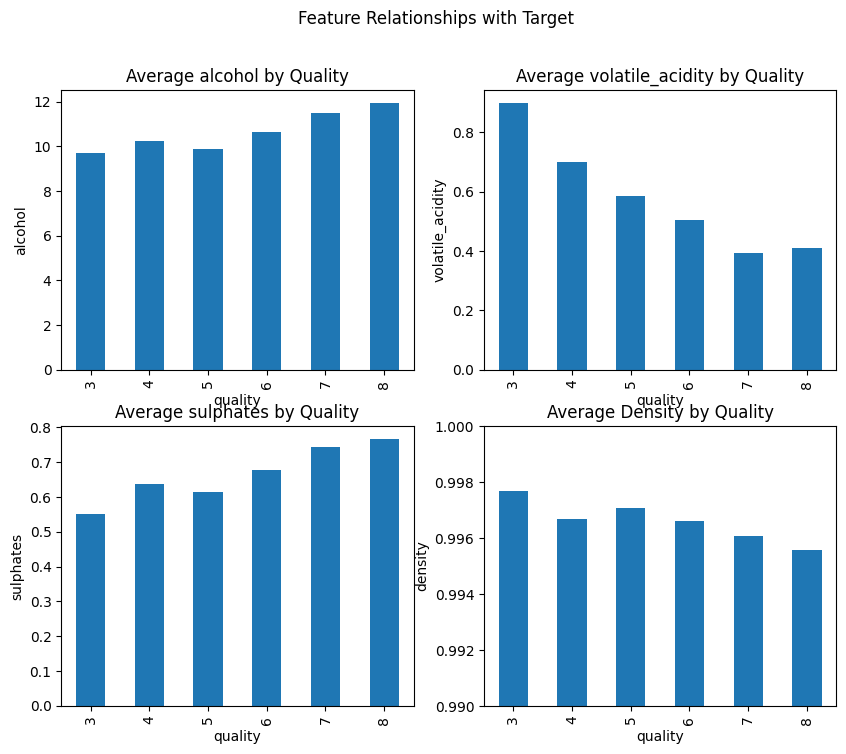

<Figure size 640x480 with 0 Axes>

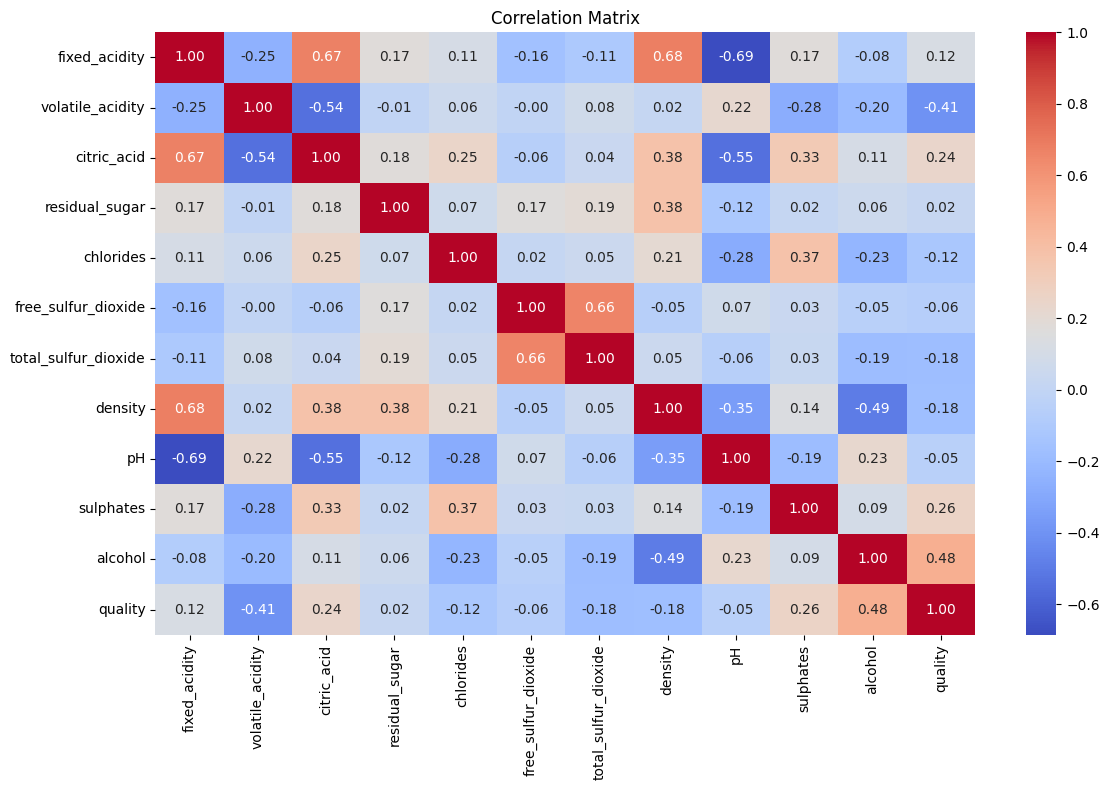

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# df
assert "df" in globals(), "Run the data-loading cell above first."

# 1. histogram
df.hist(figsize=(12, 10), bins=20)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

# 2. bar plot - relationships with target
important = ['alcohol', 'volatile_acidity', 'sulphates', 'density']
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for i, feature in enumerate(important):
    df.groupby('quality')[feature].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Average {feature} by Quality')
    axes[i].set_xlabel('quality')
    axes[i].set_ylabel(feature)
plt.suptitle('Feature Relationships with Target')
# just for density, zoom in on the y axis
df.groupby('quality')['density'].mean().plot(kind='bar')
plt.title('Average Density by Quality')
plt.ylim(0.99, 1.00)  # zoom in
plt.show()
plt.tight_layout()
plt.show()

# 3. correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

Cluster profile (means):
          alcohol  volatile_acidity  sulphates  density  quality
cluster                                                        
0           9.83              0.62       0.57     1.00     5.27
1          11.83              0.46       0.67     0.99     6.22
2          10.27              0.43       0.83     1.00     5.90


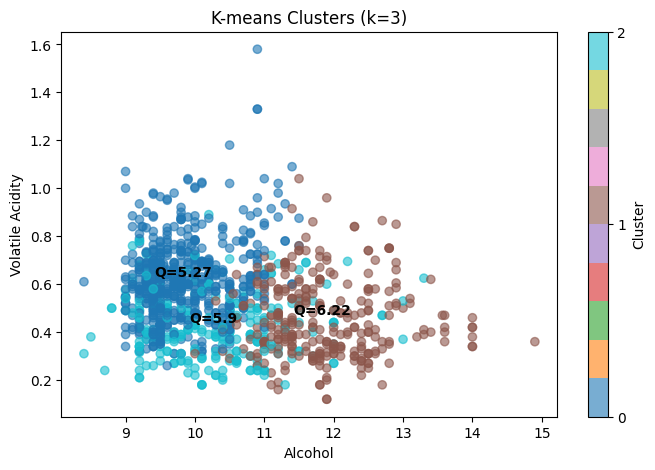

In [ ]:
# Import libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Fill missing values
df.fillna(df.median(), inplace=True)

# Use the 4 features from your EDA
features = ['alcohol', 'volatile_acidity', 'sulphates', 'density']
X_km = df[features]

# Scale the features
scaler = StandardScaler()
X_km_scaled = scaler.fit_transform(X_km)

# Fit K-means with k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_km_scaled)

# give each cluster stats
profile = df.groupby('cluster')[['alcohol', 'volatile_acidity', 'sulphates', 'density', 'quality']].mean().round(2)
print("Cluster profile (means):\n", profile)


# give each cluster color
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['alcohol'], df['volatile_acidity'],c=df['cluster'], cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Cluster', ticks=[0, 1, 2])
plt.xlabel('Alcohol')
plt.ylabel('Volatile Acidity')
plt.title('K-means Clusters (k=3)')

for cluster_id, row in profile.iterrows():
    plt.text(row['alcohol'], row['volatile_acidity'],
             f"Q={row['quality']}", fontsize=10, fontweight='bold', 
             ha='center', va='bottom', color='black')

plt.show()

,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.816594,1.000000,1.000000,0.805580,0.816594
1,3,0.893431,0.834061,0.878466,0.893431,0.827478,0.834061
2,5,0.864234,0.855895,0.827704,0.864234,0.847307,0.855895
3,7,0.843796,0.838428,0.801282,0.843796,0.795872,0.838428
4,9,0.842336,0.847162,0.796220,0.842336,0.803619,0.847162
5,11,0.839416,0.851528,0.790643,0.839416,0.812227,0.851528


,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.829694,1.000000,1.000000,0.813589,0.829694
1,3,0.884672,0.847162,0.870901,0.884672,0.835945,0.847162
2,5,0.856934,0.868996,0.851992,0.856934,0.867433,0.868996
3,7,0.856934,0.855895,0.817144,0.856934,0.815320,0.855895
4,9,0.861314,0.860262,0.822282,0.861314,0.820472,0.860262
5,11,0.845255,0.842795,0.800584,0.845255,0.796158,0.842795


,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.820961,1.000000,1.000000,0.815466,0.820961
1,3,0.896350,0.855895,0.888867,0.896350,0.846605,0.855895
2,5,0.856934,0.860262,0.851047,0.856934,0.823798,0.860262
3,7,0.858394,0.868996,0.819701,0.858394,0.831265,0.868996
4,9,0.855474,0.864629,0.814908,0.855474,0.825942,0.864629
5,11,0.845255,0.860262,0.799757,0.845255,0.820639,0.860262


,k,train_acc,val_acc,train_precision,train_recall,val_precision,val_recall
0,1,1.000000,0.834061,1.000000,1.000000,0.820132,0.834061
1,3,0.893431,0.838428,0.878150,0.893431,0.825684,0.838428
2,5,0.870073,0.842795,0.833338,0.870073,0.797289,0.842795
3,7,0.858394,0.851528,0.819542,0.858394,0.808964,0.851528
4,9,0.854015,0.847162,0.812628,0.854015,0.803619,0.847162
5,11,0.849635,0.855895,0.806381,0.849635,0.818189,0.855895


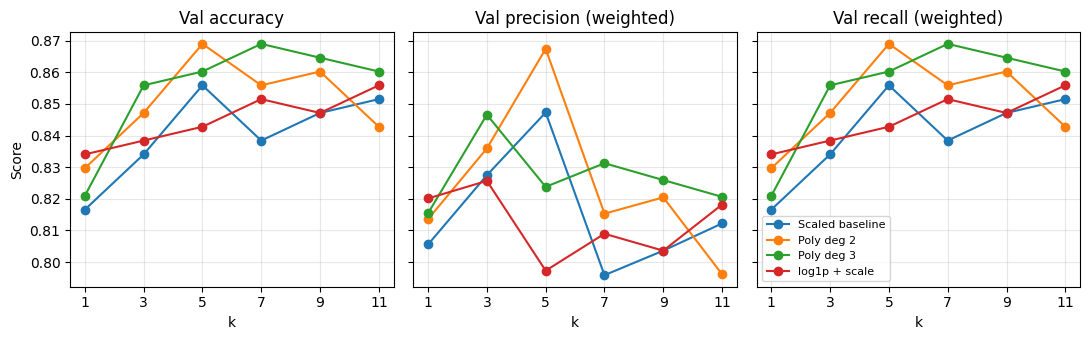

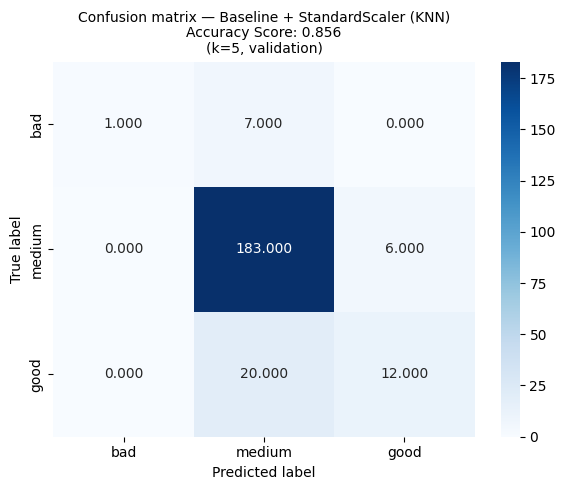

In [21]:

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score
import seaborn as sns

# Three quality buckets: bad (<5), medium ([5,7)), good (>=7)
y_bucket = np.select(
    [
        df["quality"].values < 5,
        (df["quality"].values >= 5) & (df["quality"].values < 7),
        df["quality"].values >= 7,
    ],
    [0, 1, 2],
    default=-1,
)

feature_cols = [
    "fixed_acidity","volatile_acidity","citric_acid","residual_sugar","chlorides","free_sulfur_dioxide","total_sulfur_dioxide","density","pH","sulphates","alcohol",
]
X = df[feature_cols]

# 60% train / 20% validation / 20% test
X_temp, X_test_unused, y_temp, y_test_unused = train_test_split(
    X,
    y_bucket,
    test_size=0.2,
    random_state=42,
    stratify=y_bucket,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp,
)

X_train = np.asarray(X_train, dtype=float)
X_val = np.asarray(X_val, dtype=float)

k_values = [1, 3, 5, 7, 9, 11]
# choose these odd values to prevent ties and i wanted 6 evenly spaced off values from very local/ flexible to a more structured/smooth model by the end which would test high bias/low variance ( stopped at 11 because there were only 11 features)

# Baseline: original features + StandardScaler (preprocessing)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

knn_results = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights="uniform")
    knn.fit(X_train_scaled, y_train)
    knn_results.append({
        "k": k,
        "train_acc": knn.score(X_train_scaled, y_train),
        "val_acc": knn.score(X_val_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_scaled), average="weighted", zero_division=0),
    })

# Polynomial degree 2: squared, then scale for KNN. Degree 2 adds squares and is a more complex model class, I wanted to test it out to see if pattern was better than the linear one
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

scaler_poly = StandardScaler()
X_train_poly2_scaled = scaler_poly.fit_transform(X_train_poly)
X_val_poly2_scaled = scaler_poly.transform(X_val_poly)

knn_results_poly = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_poly2_scaled, y_train)
    knn_results_poly.append({
        "k": k,
        "train_acc": knn.score(X_train_poly2_scaled, y_train),
        "val_acc": knn.score(X_val_poly2_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_poly2_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_poly2_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_poly2_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_poly2_scaled), average="weighted", zero_division=0),
    })

# Polynomial degree 3: degree 2 helped out a little bit in some of the features so I tried 3rd degree to compensate for the fact that there were 11 features and probably needed a higher order to map correctly
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_val_poly3 = poly3.transform(X_val)

scaler_poly3 = StandardScaler()
X_train_poly3_scaled = scaler_poly3.fit_transform(X_train_poly3)
X_val_poly3_scaled = scaler_poly3.transform(X_val_poly3)

knn_results_poly3 = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_poly3_scaled, y_train)
    knn_results_poly3.append({
        "k": k,
        "train_acc": knn.score(X_train_poly3_scaled, y_train),
        "val_acc": knn.score(X_val_poly3_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_poly3_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_poly3_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_poly3_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_poly3_scaled), average="weighted", zero_division=0),
    })

# Log transformation: a lot of the inputs are right skewed, the log will help compress larger values making it less sensitive to outliers.
X_train_log = np.log1p(np.maximum(X_train, 0.0))
X_val_log = np.log1p(np.maximum(X_val, 0.0))

scaler_log = StandardScaler()
X_train_log_scaled = scaler_log.fit_transform(X_train_log)
X_val_log_scaled = scaler_log.transform(X_val_log)

knn_results_log = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_log_scaled, y_train)
    knn_results_log.append({
        "k": k,
        "train_acc": knn.score(X_train_log_scaled, y_train),
        "val_acc": knn.score(X_val_log_scaled, y_val),
        "train_precision": precision_score(y_train, knn.predict(X_train_log_scaled), average="weighted", zero_division=0),
        "train_recall": recall_score(y_train, knn.predict(X_train_log_scaled), average="weighted", zero_division=0),
        "val_precision": precision_score(y_val, knn.predict(X_val_log_scaled), average="weighted", zero_division=0),
        "val_recall": recall_score(y_val, knn.predict(X_val_log_scaled), average="weighted", zero_division=0),
    })

display(pd.DataFrame(knn_results))
display(pd.DataFrame(knn_results_poly))
display(pd.DataFrame(knn_results_poly3))
display(pd.DataFrame(knn_results_log))

transformations = [
    ("Scaled baseline", knn_results),
    ("Poly deg 2", knn_results_poly),
    ("Poly deg 3", knn_results_poly3),
    ("log1p + scale", knn_results_log),
]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)

metrics = [
    (axes[0], "Val accuracy","val_acc"),
    (axes[1], "Val precision (weighted)","val_precision"),
    (axes[2], "Val recall (weighted)","val_recall"),
]

for ax, title, key in metrics:
    for name, rows in transformations:
        ks     = [r["k"]  for r in rows]
        scores = [r[key]  for r in rows]
        ax.plot(ks, scores, marker="o", label=name)
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Score")
axes[-1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Confusion matrix for the baseline at its best k
cm_labels = ["bad", "medium", "good"]

best_k = max(knn_results, key=lambda r: r["val_acc"])["k"]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred = knn_best.predict(X_val_scaled)

cm  = confusion_matrix(y_val, y_pred, labels=[0, 1, 2])
acc = accuracy_score(y_val, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm.astype(float), annot=True, fmt=".3f", cmap="Blues", ax=ax,
    xticklabels=cm_labels, yticklabels=cm_labels, vmin=0,
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(
    f"Confusion matrix — Baseline + StandardScaler (KNN)\nAccuracy Score: {acc:.3f}\n(k={best_k}, validation)",
    fontsize=10,
)
plt.tight_layout()
plt.show()


In [8]:
# Logistic Regression (same 3-class labels and train/val split as KNN cell above)
from sklearn.linear_model import LogisticRegression

scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr = scaler_lr.transform(X_val)

C_values = [0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
lr_results = []
for C in C_values:
    lr = LogisticRegression(C=C, max_iter=5000, random_state=42)
    lr.fit(X_train_lr, y_train)
    lr_results.append(
        {
            "C": C,
            "train_acc": lr.score(X_train_lr, y_train),
            "val_acc": lr.score(X_val_lr, y_val),
        }
    )

display(pd.DataFrame(lr_results))


,C,train_acc,val_acc
0,0.01,0.833577,0.834061
1,0.10,0.852555,0.855895
2,0.50,0.851095,0.851528
3,1.00,0.852555,0.847162
4,10.00,0.854015,0.847162
5,100.00,0.854015,0.847162


In [9]:
# Linear Regression + Ridge / Lasso on continuous quality (numeric target)
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

feature_cols_reg = [
    "fixed_acidity",
    "volatile_acidity",
    "citric_acid",
    "residual_sugar",
    "chlorides",
    "free_sulfur_dioxide",
    "total_sulfur_dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]
Xr = df[feature_cols_reg].astype(float)
yr = df["quality"].astype(float)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

scaler_r = StandardScaler()
Xtr_s = scaler_r.fit_transform(X_tr_r)
Xte_s = scaler_r.transform(X_te_r)

lin = LinearRegression()
lin.fit(Xtr_s, y_tr_r)
pred_lin = lin.predict(Xte_s)
print(
    "LinearRegression — MSE:",
    mean_squared_error(y_te_r, pred_lin),
    "R²:",
    r2_score(y_te_r, pred_lin),
)

alpha_values = [0.01, 0.1, 0.5, 1.0, 10.0, 100.0]
print("\nRidge:")
for alpha in alpha_values:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(Xtr_s, y_tr_r)
    pred = ridge.predict(Xte_s)
    print(
        f"  alpha={alpha:<6} RMSE={mean_squared_error(y_te_r, pred) ** 0.5:.4f}  R²={r2_score(y_te_r, pred):.4f}"
    )

print("\nLasso:")
for alpha in alpha_values:
    lasso = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    lasso.fit(Xtr_s, y_tr_r)
    pred = lasso.predict(Xte_s)
    print(
        f"  alpha={alpha:<6} RMSE={mean_squared_error(y_te_r, pred) ** 0.5:.4f}  R²={r2_score(y_te_r, pred):.4f}"
    )


LinearRegression — MSE: 0.38003245026277505 R²: 0.31706936727331314

Ridge:
  alpha=0.01   RMSE=0.6165  R²=0.3171
  alpha=0.1    RMSE=0.6165  R²=0.3171
  alpha=0.5    RMSE=0.6164  R²=0.3172
  alpha=1.0    RMSE=0.6163  R²=0.3173
  alpha=10.0   RMSE=0.6153  R²=0.3196
  alpha=100.0  RMSE=0.6091  R²=0.3332

Lasso:
  alpha=0.01   RMSE=0.6082  R²=0.3353
  alpha=0.1    RMSE=0.6182  R²=0.3133
  alpha=0.5    RMSE=0.7460  R²=-0.0000
  alpha=1.0    RMSE=0.7460  R²=-0.0000
  alpha=10.0   RMSE=0.7460  R²=-0.0000
  alpha=100.0  RMSE=0.7460  R²=-0.0000
